In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [2]:
# =================================================================
# STEP 1: LOADING AND MERGING DATA
# =================================================================
# Load the movie metadata and credits datasets
movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

In [3]:
# Merging both files on 'id' to create a single comprehensive dataframe
df = movies.merge(credits, left_on='id', right_on='movie_id')


In [16]:
# Display the first 5 rows to verify the data is read correctly
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,spoken_languages,status,tagline,title_x,vote_average,vote_count,movie_id,title_y,cast,crew
0,237000000,"[Action, Adventure, Fantasy, Science Fiction]",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[Adventure, Fantasy, Action]",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[Action, Adventure, Crime]",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[Action, Crime, Drama, Thriller]",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[Action, Adventure, Science Fiction]",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [4]:
# =================================================================
# STEP 2: DATA CLEANING & TRANSFORMATION
# =================================================================
# The 'genres' column is in a JSON string format.
# We define a function to extract just the names into a clean list.
def clean_json_column(column_data):
    return [item['name'] for item in json.loads(column_data)]

df['genres'] = df['genres'].apply(clean_json_column)

In [5]:
# Filtering out rows with 0 revenue or budget to ensure financial trends are valid
df = df[(df['revenue'] > 0) & (df['budget'] > 0)]

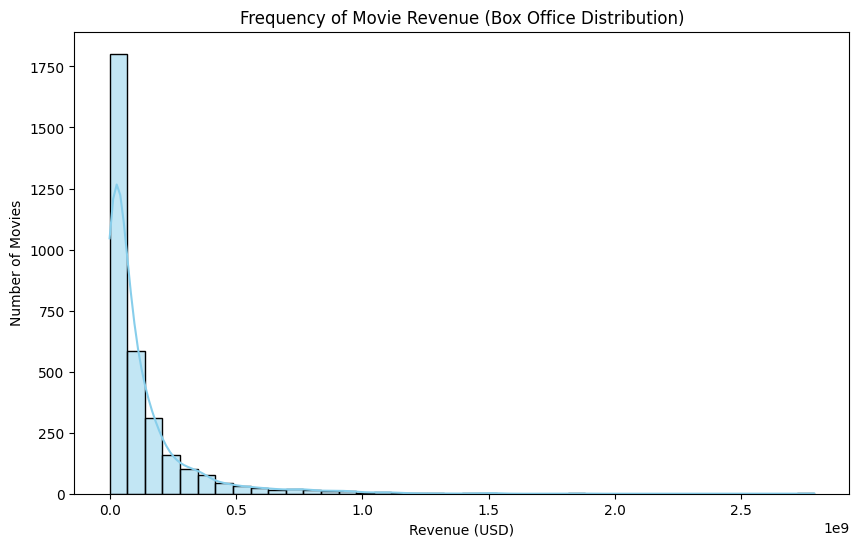

In [6]:
# STEP 3: DATA VISUALIZATION (Trends Analysis)
# =================================================================

# --- A. HISTOGRAM: Revenue Distribution ---
# Purpose: To visualize the frequency of earnings across all movies.
plt.figure(figsize=(10, 6))
sns.histplot(df['revenue'], bins=40, color='skyblue', kde=True)
plt.title('Frequency of Movie Revenue (Box Office Distribution)')
plt.xlabel('Revenue (USD)')
plt.ylabel('Number of Movies')
plt.show()

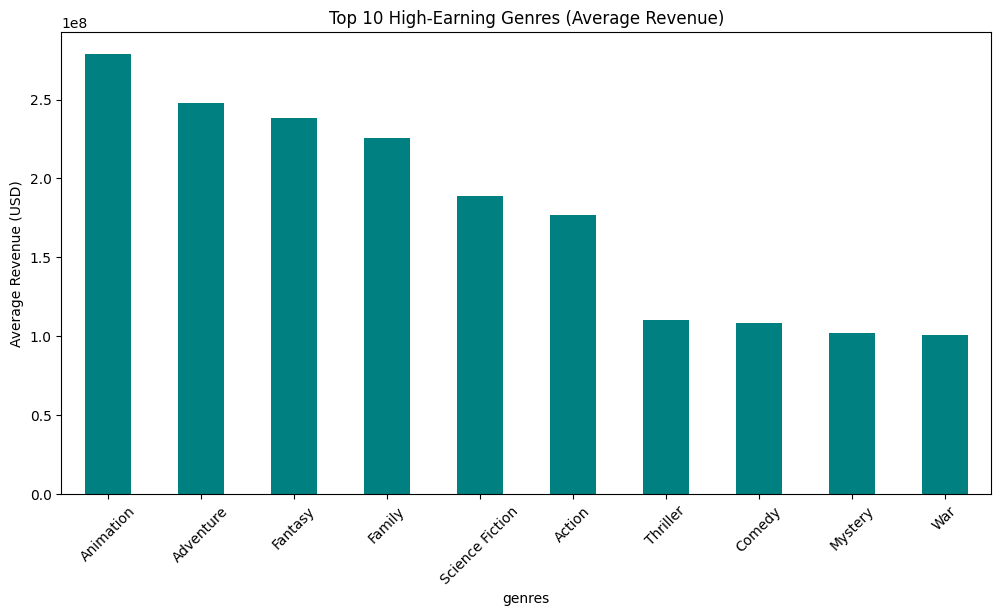

In [7]:
# --- B. BAR GRAPH: Top 10 Genres by Revenue ---
# Purpose: To compare which genres generate the highest average income.
# We 'explode' the genre lists so each genre is represented individually.
genre_exploded = df.explode('genres')
avg_revenue_by_genre = genre_exploded.groupby('genres')['revenue'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
avg_revenue_by_genre.plot(kind='bar', color='teal')
plt.title('Top 10 High-Earning Genres (Average Revenue)')
plt.ylabel('Average Revenue (USD)')
plt.xticks(rotation=45)
plt.show()

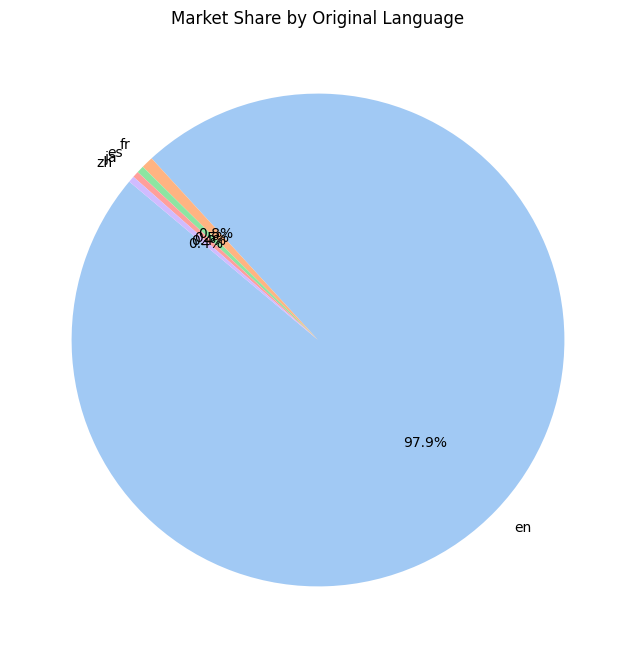

In [8]:
# --- C. PIE CHART: Language Distribution ---
# Purpose: To show the percentage share of different languages in the dataset.
top_languages = df['original_language'].value_counts().head(5)
plt.figure(figsize=(8, 8))
plt.pie(top_languages, labels=top_languages.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Market Share by Original Language')
plt.show()

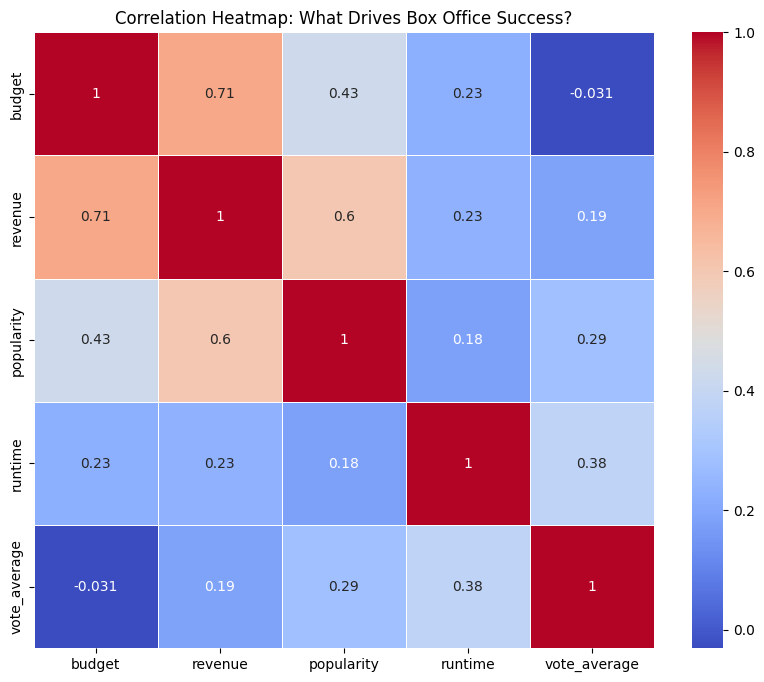

In [9]:
# --- D. HEATMAP: Feature Correlation ---
# Purpose: To see how variables like Budget and Popularity correlate with Revenue.
plt.figure(figsize=(10, 8))
numeric_cols = df[['budget', 'revenue', 'popularity', 'runtime', 'vote_average']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap: What Drives Box Office Success?')
plt.show()

In [12]:
# =================================================================
# STEP 4: MACHINE LEARNING (Revenue Prediction)
# =================================================================

# Defining our Features (Inputs) and Target (Output)
X = df[['budget', 'popularity', 'runtime']].fillna(0) # Handling missing values
y = df['revenue']

In [14]:
# Splitting data: 80% to train the model, 20% to test its accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initializing and training the Random Forest Regressor
# This model uses multiple decision trees to find complex patterns in box office trends.
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [15]:
# STEP 5: EVALUATION
# =================================================================
predictions = model.predict(X_test)
accuracy = r2_score(y_test, predictions)

print(f"--- Project Results ---")
print(f"Model Prediction Accuracy (R2 Score): {accuracy:.4f}")
# An R2 score closer to 1.0 means the model is very good at predicting revenue.

--- Project Results ---
Model Prediction Accuracy (R2 Score): 0.6214
